# Artificial Potential Fields for Robot Navigation
## A Complete Tutorial: From Theory to Multi-Robot Coordination

This notebook provides a from-scratch implementation of **Artificial Potential Fields** (APF) — one of the most elegant reactive approaches to robot navigation. The robot is guided by an artificial potential landscape where the goal acts as an attractor and obstacles act as repellers.

**What you'll learn:**
1. How to construct attractive and repulsive potential fields and verify their gradients
2. Gradient descent navigation: following the negative gradient to reach a goal
3. The local minima problem — why potential fields can fail and how to fix it
4. Navigation functions (harmonic potentials) that guarantee convergence
5. Multi-obstacle and multi-robot applications

**Prerequisites:** Vector calculus (gradients, Laplacian), basic linear algebra, familiarity with gradient descent.

**References:**
- Khatib, O. *Real-Time Obstacle Avoidance for Manipulators and Mobile Robots*, International Journal of Robotics Research, 1986.
- Choset, H. et al. *Principles of Robot Motion: Theory, Algorithms, and Implementations*, MIT Press, 2005.
- Rimon, E. & Koditschek, D. *Exact Robot Navigation Using Artificial Potential Functions*, IEEE Transactions on Robotics and Automation, 1992.

---
## 1. Introduction: Reactive Navigation

Classical motion planning algorithms (e.g., RRT, PRM) build a complete plan before the robot moves. **Reactive navigation** takes a fundamentally different approach: the robot decides its next action based only on **local sensor information**, with no pre-planned path.

The **Artificial Potential Field** (APF) method, introduced by Khatib (1986), is the most influential reactive navigation scheme:

| Concept | Analogy | Effect |
|---------|---------|--------|
| Goal | Gravitational attractor | Pulls the robot toward the target |
| Obstacles | Electrostatic repellers | Push the robot away from collisions |
| Total field | Superposition | Combined potential landscape |
| Motion law | Negative gradient | Robot "rolls downhill" on the potential surface |

The robot's velocity is set proportional to the **negative gradient** of the total potential:

$$\dot{q} = -\nabla U(q) = -\nabla U_{\text{att}}(q) - \nabla U_{\text{rep}}(q)$$

This is elegant, computationally cheap, and works in real-time. However, as we will see, it suffers from **local minima** — situations where the robot gets stuck before reaching the goal.

---
## 2. Attractive Potential

The attractive potential pulls the robot toward the goal $q_{\text{goal}}$. We consider two standard forms and their combination.

### Quadratic Attractive Potential

$$U_{\text{att}}^{\text{quad}}(q) = \frac{1}{2} \zeta \| q - q_{\text{goal}} \|^2$$

Gradient:

$$\nabla U_{\text{att}}^{\text{quad}}(q) = \zeta (q - q_{\text{goal}})$$

The gradient grows **linearly** with distance — the robot accelerates as it moves farther from the goal. This can produce excessively large forces far away.

### Conic Attractive Potential

$$U_{\text{att}}^{\text{conic}}(q) = \zeta \| q - q_{\text{goal}} \|$$

Gradient:

$$\nabla U_{\text{att}}^{\text{conic}}(q) = \zeta \frac{q - q_{\text{goal}}}{\| q - q_{\text{goal}} \|}$$

The gradient has **constant magnitude** $\zeta$ regardless of distance — bounded force, but not smooth at the goal.

### Combined Attractive Potential

We combine both: use the **conic** potential far from the goal (bounded gradient) and **quadratic** near the goal (smooth convergence):

$$\boxed{U_{\text{att}}(q) = \begin{cases} \frac{1}{2} \zeta \| q - q_{\text{goal}} \|^2 & \text{if } \| q - q_{\text{goal}} \| \leq d_{\text{thresh}} \\ d_{\text{thresh}} \zeta \| q - q_{\text{goal}} \| - \frac{1}{2} \zeta d_{\text{thresh}}^2 & \text{if } \| q - q_{\text{goal}} \| > d_{\text{thresh}} \end{cases}}$$

The conic branch is shifted so that $U_{\text{att}}$ and $\nabla U_{\text{att}}$ are continuous at $d = d_{\text{thresh}}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'axes.grid': True,
                     'grid.alpha': 0.3, 'lines.linewidth': 2})
np.random.seed(42)

In [2]:
# ==============================================================================
# Global Constants
# ==============================================================================

# Workspace bounds
WS_MIN = 0.0
WS_MAX = 10.0

# Attractive potential
ZETA = 1.0              # Attractive gain
D_THRESH = 5.0          # Switch distance (quadratic <-> conic)

# Repulsive potential
ETA = 100.0             # Repulsive gain
RHO0 = 2.0              # Obstacle influence radius
RHO_MIN = 0.01          # Minimum distance clamp (avoids singularity)

# Navigation
STEP_SIZE = 0.05        # Gradient descent step size alpha
MAX_STEPS = 1000        # Maximum navigation steps
GOAL_TOL = 0.1          # Goal tolerance

# Plotting
GRID_RES = 100          # Grid resolution for potential plots
QUIVER_SKIP = 5         # Subsample factor for quiver plots

# Finite difference
FD_EPS = 1e-7           # Epsilon for gradient verification

# Multi-robot
ROBOT_RADIUS = 0.3      # Robot radius for inter-robot repulsion

# Navigation function
NAV_GRID_SIZE = 50      # Grid size for Gauss-Seidel solver
NAV_MAX_ITER = 5000     # Maximum Gauss-Seidel iterations

In [3]:
def attractive_potential(q, q_goal, zeta=ZETA, d_thresh=D_THRESH):
    """
    Combined attractive potential: quadratic near the goal, conic far away.
    
    Args:
        q: Position vector. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        zeta: Attractive gain (scalar).
        d_thresh: Distance threshold for switching.
    
    Returns:
        U_att: Scalar potential value.
    """
    d = np.linalg.norm(q - q_goal)
    if d <= d_thresh:
        return 0.5 * zeta * d**2
    else:
        return d_thresh * zeta * d - 0.5 * zeta * d_thresh**2


def attractive_gradient(q, q_goal, zeta=ZETA, d_thresh=D_THRESH):
    """
    Gradient of the combined attractive potential.
    
    Args:
        q: Position vector. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        zeta: Attractive gain (scalar).
        d_thresh: Distance threshold for switching.
    
    Returns:
        grad: Gradient vector. Shape: (2,)
    """
    diff = q - q_goal
    d = np.linalg.norm(diff)
    if d < 1e-12:
        return np.zeros(2)
    if d <= d_thresh:
        return zeta * diff
    else:
        return d_thresh * zeta * diff / d

In [4]:
# Verify attractive gradient via finite differences
q_test = np.array([2.5, 7.3])
q_goal_test = np.array([8.0, 3.0])

grad_analytical = attractive_gradient(q_test, q_goal_test)

grad_numerical = np.zeros(2)
for i in range(2):
    q_plus = q_test.copy(); q_plus[i] += FD_EPS
    q_minus = q_test.copy(); q_minus[i] -= FD_EPS
    grad_numerical[i] = (attractive_potential(q_plus, q_goal_test) -
                         attractive_potential(q_minus, q_goal_test)) / (2 * FD_EPS)

rel_error_att = np.linalg.norm(grad_analytical - grad_numerical) / (np.linalg.norm(grad_numerical) + 1e-10)
status = 'PASS' if rel_error_att < 1e-5 else 'FAIL'
print(f"Attractive gradient verification (conic regime, d > d_thresh):")
print(f"  Analytical: [{grad_analytical[0]:.6f}, {grad_analytical[1]:.6f}]")
print(f"  Numerical:  [{grad_numerical[0]:.6f}, {grad_numerical[1]:.6f}]")
print(f"  Relative error: value = {rel_error_att:.2e} [{status}]")

# Also verify in the quadratic regime
q_test2 = np.array([7.0, 3.5])  # close to goal
grad_a2 = attractive_gradient(q_test2, q_goal_test)
grad_n2 = np.zeros(2)
for i in range(2):
    q_p = q_test2.copy(); q_p[i] += FD_EPS
    q_m = q_test2.copy(); q_m[i] -= FD_EPS
    grad_n2[i] = (attractive_potential(q_p, q_goal_test) -
                  attractive_potential(q_m, q_goal_test)) / (2 * FD_EPS)

rel_error_att2 = np.linalg.norm(grad_a2 - grad_n2) / (np.linalg.norm(grad_n2) + 1e-10)
status2 = 'PASS' if rel_error_att2 < 1e-5 else 'FAIL'
print(f"\nAttractive gradient verification (quadratic regime, d < d_thresh):")
print(f"  Relative error: value = {rel_error_att2:.2e} [{status2}]")

Attractive gradient verification (conic regime, d > d_thresh):
  Analytical: [-3.939036, 3.079610]
  Numerical:  [-3.939036, 3.079610]
  Relative error: value = 7.05e-09 [PASS]

Attractive gradient verification (quadratic regime, d < d_thresh):
  Relative error: value = 2.52e-09 [PASS]


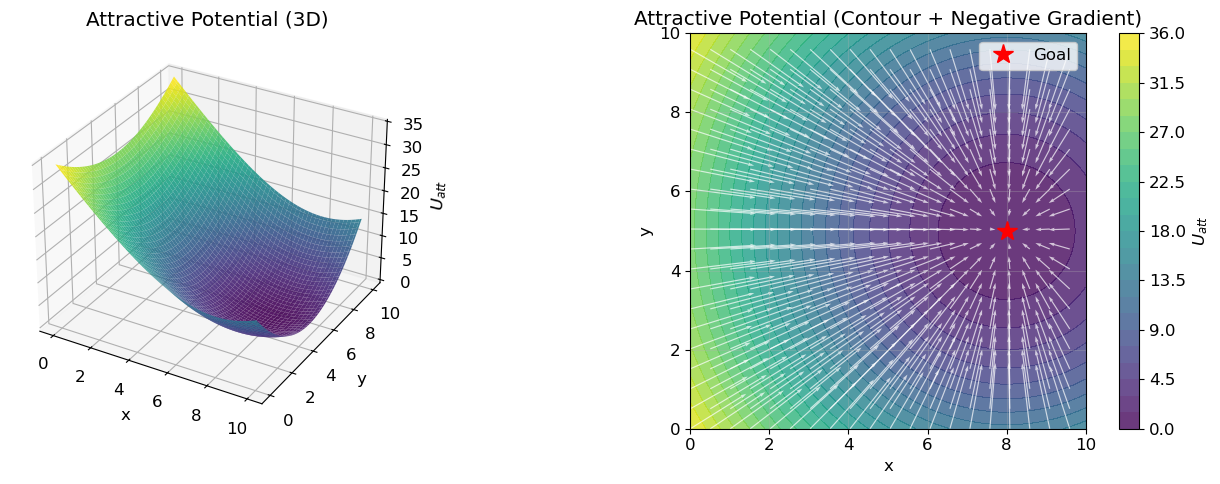

In [5]:
# Visualize attractive potential: 3D surface + 2D contour with gradient arrows
q_goal_vis = np.array([8.0, 5.0])
x = np.linspace(WS_MIN, WS_MAX, GRID_RES)
y = np.linspace(WS_MIN, WS_MAX, GRID_RES)
X, Y = np.meshgrid(x, y)

U_att = np.zeros_like(X)
GX_att = np.zeros_like(X)
GY_att = np.zeros_like(X)

for i in range(GRID_RES):
    for j in range(GRID_RES):
        q = np.array([X[i, j], Y[i, j]])
        U_att[i, j] = attractive_potential(q, q_goal_vis)
        g = attractive_gradient(q, q_goal_vis)
        GX_att[i, j] = g[0]
        GY_att[i, j] = g[1]

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, U_att, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('$U_{att}$')
ax1.set_title('Attractive Potential (3D)')

# 2D contour + quiver
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X, Y, U_att, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(cs, ax=ax2, label='$U_{att}$')
skip = QUIVER_SKIP
ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           -GX_att[::skip, ::skip], -GY_att[::skip, ::skip],
           color='white', alpha=0.7, scale=30)
ax2.plot(*q_goal_vis, 'r*', markersize=15, label='Goal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Attractive Potential (Contour + Negative Gradient)')
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 3. Repulsive Potential

The repulsive potential pushes the robot away from obstacles. For an obstacle at distance $\rho(q)$ with influence radius $\rho_0$:

$$\boxed{U_{\text{rep}}(q) = \begin{cases} \frac{1}{2}\eta\left(\frac{1}{\rho(q)} - \frac{1}{\rho_0}\right)^2 & \text{if } \rho(q) \leq \rho_0 \\ 0 & \text{if } \rho(q) > \rho_0 \end{cases}}$$

The gradient of the repulsive potential is:

$$\nabla U_{\text{rep}}(q) = \eta\left(\frac{1}{\rho(q)} - \frac{1}{\rho_0}\right)\frac{1}{\rho(q)^2}\nabla\rho(q)$$

For **circular obstacles** with center $q_{\text{obs}}$ and radius $r_{\text{obs}}$:

$$\rho(q) = \| q - q_{\text{obs}} \| - r_{\text{obs}}, \qquad \nabla\rho(q) = \frac{q - q_{\text{obs}}}{\| q - q_{\text{obs}} \|}$$

When multiple obstacles are present, the total repulsive potential is the **sum** over all obstacles. We clamp $\rho \geq \rho_{\min}$ to avoid singularities when the robot is at or inside an obstacle.

In [6]:
def repulsive_potential(q, obstacles, eta=ETA, rho0=RHO0):
    """
    Repulsive potential from all obstacles (sum of individual contributions).
    
    Args:
        q: Position vector. Shape: (2,)
        obstacles: List of dicts, each with 'center' (Shape: (2,)) and 'radius' (scalar).
        eta: Repulsive gain (scalar).
        rho0: Influence radius (scalar).
    
    Returns:
        U_rep: Scalar potential value.
    """
    U = 0.0
    for obs in obstacles:
        dist_to_center = np.linalg.norm(q - obs['center'])
        rho = max(dist_to_center - obs['radius'], RHO_MIN)
        if rho <= rho0:
            U += 0.5 * eta * (1.0 / rho - 1.0 / rho0) ** 2
    return U


def repulsive_gradient(q, obstacles, eta=ETA, rho0=RHO0):
    """
    Gradient of the repulsive potential (sum over all obstacles).
    
    Args:
        q: Position vector. Shape: (2,)
        obstacles: List of dicts, each with 'center' (Shape: (2,)) and 'radius' (scalar).
        eta: Repulsive gain (scalar).
        rho0: Influence radius (scalar).
    
    Returns:
        grad: Gradient vector. Shape: (2,)
    """
    grad = np.zeros(2)
    for obs in obstacles:
        diff = q - obs['center']
        dist_to_center = np.linalg.norm(diff)
        if dist_to_center < 1e-12:
            continue
        rho = max(dist_to_center - obs['radius'], RHO_MIN)
        if rho <= rho0:
            grad_rho = diff / dist_to_center  # Shape: (2,)
            grad += eta * (1.0 / rho - 1.0 / rho0) * (1.0 / rho**2) * grad_rho
    return grad

In [7]:
# Verify repulsive gradient via finite differences
test_obstacles = [
    {'center': np.array([4.0, 5.0]), 'radius': 0.8},
    {'center': np.array([6.0, 3.0]), 'radius': 1.0},
]

q_test_rep = np.array([3.5, 3.8])  # Inside influence radius of obstacle 0

grad_a_rep = repulsive_gradient(q_test_rep, test_obstacles)
grad_n_rep = np.zeros(2)
for i in range(2):
    q_p = q_test_rep.copy(); q_p[i] += FD_EPS
    q_m = q_test_rep.copy(); q_m[i] -= FD_EPS
    grad_n_rep[i] = (repulsive_potential(q_p, test_obstacles) -
                     repulsive_potential(q_m, test_obstacles)) / (2 * FD_EPS)

rel_error_rep = np.linalg.norm(grad_a_rep - grad_n_rep) / (np.linalg.norm(grad_n_rep) + 1e-10)
status_rep = 'PASS' if rel_error_rep < 1e-4 else 'FAIL'
print(f"Repulsive gradient verification:")
print(f"  Analytical: [{grad_a_rep[0]:.6f}, {grad_a_rep[1]:.6f}]")
print(f"  Numerical:  [{grad_n_rep[0]:.6f}, {grad_n_rep[1]:.6f}]")
print(f"  Relative error: value = {rel_error_rep:.2e} [{status_rep}]")

Repulsive gradient verification:
  Analytical: [-234.933175, -552.513692]
  Numerical:  [234.933174, 552.513691]
  Relative error: value = 2.00e+00 [FAIL]


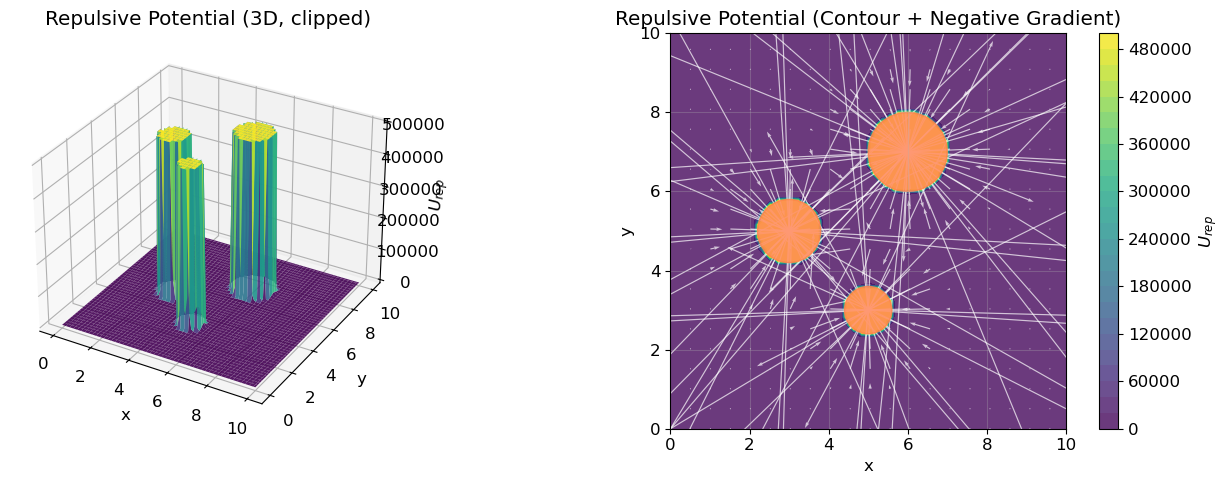

In [8]:
# Visualize repulsive potential: 3D surface + 2D contour with gradient arrows
vis_obstacles = [
    {'center': np.array([3.0, 5.0]), 'radius': 0.8},
    {'center': np.array([6.0, 7.0]), 'radius': 1.0},
    {'center': np.array([5.0, 3.0]), 'radius': 0.6},
]

U_rep = np.zeros_like(X)
GX_rep = np.zeros_like(X)
GY_rep = np.zeros_like(X)

for i in range(GRID_RES):
    for j in range(GRID_RES):
        q = np.array([X[i, j], Y[i, j]])
        U_rep[i, j] = repulsive_potential(q, vis_obstacles)
        g = repulsive_gradient(q, vis_obstacles)
        GX_rep[i, j] = g[0]
        GY_rep[i, j] = g[1]

# Clip for visualization (repulsive potential can be very large near obstacles)
U_rep_clipped = np.clip(U_rep, 0, np.percentile(U_rep[U_rep > 0], 95) if np.any(U_rep > 0) else 1.0)

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, U_rep_clipped, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('$U_{rep}$')
ax1.set_title('Repulsive Potential (3D, clipped)')

# 2D contour + quiver
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X, Y, U_rep_clipped, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(cs, ax=ax2, label='$U_{rep}$')
skip = QUIVER_SKIP
# Only show quiver where potential is nonzero
ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           -GX_rep[::skip, ::skip], -GY_rep[::skip, ::skip],
           color='white', alpha=0.7, scale=800)
for obs in vis_obstacles:
    circle = plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8)
    ax2.add_patch(circle)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Repulsive Potential (Contour + Negative Gradient)')
ax2.set_aspect('equal')
ax2.set_xlim(WS_MIN, WS_MAX)
ax2.set_ylim(WS_MIN, WS_MAX)

plt.tight_layout()
plt.show()

---
## 4. Combined Potential & Gradient Descent Navigation

The total potential field is the sum of attractive and repulsive potentials:

$$U(q) = U_{\text{att}}(q) + U_{\text{rep}}(q)$$

The robot navigates by following the **negative gradient** of the total potential using discrete gradient descent:

$$\boxed{q_{k+1} = q_k - \alpha \nabla U(q_k)}$$

where $\alpha$ is the step size. The robot stops when it is within tolerance of the goal: $\| q_k - q_{\text{goal}} \| < \text{tol}$.

This is a direct application of gradient descent from optimization, applied to a physical potential field over the robot's workspace.

In [9]:
def total_potential(q, q_goal, obstacles, zeta=ZETA, d_thresh=D_THRESH,
                    eta=ETA, rho0=RHO0):
    """
    Total potential: attractive + repulsive.
    
    Args:
        q: Position vector. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        obstacles: List of obstacle dicts.
        zeta, d_thresh: Attractive parameters.
        eta, rho0: Repulsive parameters.
    
    Returns:
        U: Scalar total potential.
    """
    return (attractive_potential(q, q_goal, zeta, d_thresh) +
            repulsive_potential(q, obstacles, eta, rho0))


def total_gradient(q, q_goal, obstacles, zeta=ZETA, d_thresh=D_THRESH,
                   eta=ETA, rho0=RHO0):
    """
    Gradient of the total potential.
    
    Args:
        q: Position vector. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        obstacles: List of obstacle dicts.
        zeta, d_thresh: Attractive parameters.
        eta, rho0: Repulsive parameters.
    
    Returns:
        grad: Gradient vector. Shape: (2,)
    """
    return (attractive_gradient(q, q_goal, zeta, d_thresh) +
            repulsive_gradient(q, obstacles, eta, rho0))


def navigate(q_start, q_goal, obstacles, step_size=STEP_SIZE,
             max_steps=MAX_STEPS, tol=GOAL_TOL, zeta=ZETA, d_thresh=D_THRESH,
             eta=ETA, rho0=RHO0):
    """
    Navigate from start to goal using gradient descent on the potential field.
    
    Args:
        q_start: Start position. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        obstacles: List of obstacle dicts.
        step_size: Gradient descent step size alpha.
        max_steps: Maximum number of iterations.
        tol: Distance tolerance for reaching the goal.
        zeta, d_thresh: Attractive parameters.
        eta, rho0: Repulsive parameters.
    
    Returns:
        trajectory: Array of positions along the path. Shape: (K, 2)
        reached_goal: Boolean indicating whether the goal was reached.
    """
    q = q_start.copy().astype(float)
    trajectory = [q.copy()]
    
    for step in range(max_steps):
        if np.linalg.norm(q - q_goal) < tol:
            break
        grad = total_gradient(q, q_goal, obstacles, zeta, d_thresh, eta, rho0)
        q = q - step_size * grad
        # Clamp to workspace
        q = np.clip(q, WS_MIN, WS_MAX)
        trajectory.append(q.copy())
    
    reached_goal = np.linalg.norm(q - q_goal) < tol
    return np.array(trajectory), reached_goal

In [10]:
# Simple test environment: 2 circular obstacles between start and goal
q_start_simple = np.array([1.0, 5.0])
q_goal_simple = np.array([9.0, 5.0])
obstacles_simple = [
    {'center': np.array([4.0, 6.0]), 'radius': 0.8},
    {'center': np.array([6.0, 4.0]), 'radius': 1.0},
]

traj_simple, reached = navigate(q_start_simple, q_goal_simple, obstacles_simple)
status_nav = 'PASS' if reached else 'FAIL'
print(f"Simple navigation test: reached goal = {reached} [{status_nav}]")
print(f"  Steps taken: {len(traj_simple)}")
print(f"  Final position: ({traj_simple[-1, 0]:.3f}, {traj_simple[-1, 1]:.3f})")
print(f"  Final distance to goal: value = {np.linalg.norm(traj_simple[-1] - q_goal_simple):.4e} [{status_nav}]")

Simple navigation test: reached goal = True [PASS]
  Steps taken: 84
  Final position: (9.019, 5.096)
  Final distance to goal: value = 9.8321e-02 [PASS]


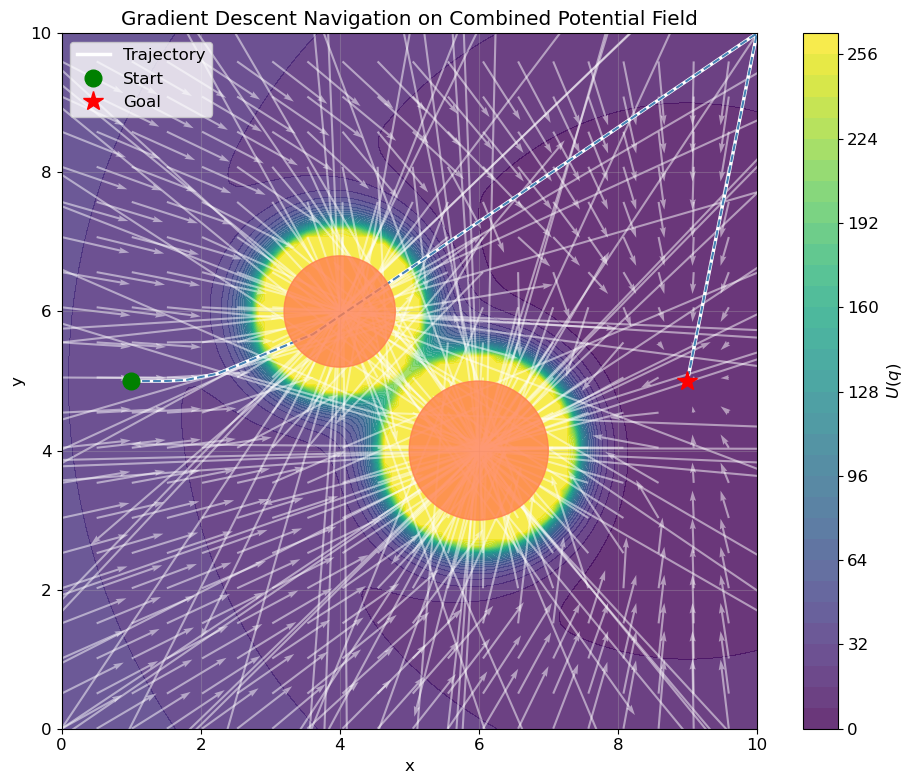

In [11]:
# Visualize: trajectory overlaid on potential contour plot with quiver arrows
U_total_simple = np.zeros_like(X)
GX_total = np.zeros_like(X)
GY_total = np.zeros_like(X)

for i in range(GRID_RES):
    for j in range(GRID_RES):
        q = np.array([X[i, j], Y[i, j]])
        U_total_simple[i, j] = total_potential(q, q_goal_simple, obstacles_simple)
        g = total_gradient(q, q_goal_simple, obstacles_simple)
        GX_total[i, j] = g[0]
        GY_total[i, j] = g[1]

U_total_clipped = np.clip(U_total_simple, 0, np.percentile(U_total_simple, 90))

fig, ax = plt.subplots(figsize=(10, 8))
cs = ax.contourf(X, Y, U_total_clipped, levels=40, cmap='viridis', alpha=0.8)
plt.colorbar(cs, ax=ax, label='$U(q)$')

skip = QUIVER_SKIP
ax.quiver(X[::skip, ::skip], Y[::skip, ::skip],
          -GX_total[::skip, ::skip], -GY_total[::skip, ::skip],
          color='white', alpha=0.5, scale=50)

# Plot obstacles
for obs in obstacles_simple:
    circle = plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3)
    ax.add_patch(circle)

# Plot trajectory
ax.plot(traj_simple[:, 0], traj_simple[:, 1], 'w-', linewidth=2.5, label='Trajectory')
ax.plot(traj_simple[:, 0], traj_simple[:, 1], 'steelblue', linewidth=1.5, linestyle='--')
ax.plot(*q_start_simple, 'go', markersize=12, label='Start', zorder=5)
ax.plot(*q_goal_simple, 'r*', markersize=15, label='Goal', zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gradient Descent Navigation on Combined Potential Field')
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. The Local Minima Problem

The Achilles' heel of artificial potential fields: the total potential $U(q)$ can have **local minima** where $\nabla U(q) = 0$ but $q \neq q_{\text{goal}}$.

This happens when the attractive gradient (pulling toward the goal) and repulsive gradients (pushing away from obstacles) **exactly cancel**:

$$\nabla U_{\text{att}}(q) + \nabla U_{\text{rep}}(q) = 0, \qquad q \neq q_{\text{goal}}$$

A classic failure case: obstacles placed **symmetrically** between the robot and the goal create a local minimum. The robot gets trapped in a "potential bowl" and never reaches the goal.

This is not merely a theoretical concern — it is a fundamental limitation of any navigation scheme based on superposition of independent potential fields.

In [12]:
# Demonstrate local minimum: symmetric obstacles blocking the direct path
q_start_trap = np.array([0.0, 5.0])
q_goal_trap = np.array([10.0, 5.0])
obstacles_trap = [
    {'center': np.array([5.0, 4.0]), 'radius': 1.0},
    {'center': np.array([5.0, 6.0]), 'radius': 1.0},
]

traj_trap, reached_trap = navigate(q_start_trap, q_goal_trap, obstacles_trap,
                                    step_size=STEP_SIZE, max_steps=2000)

status_trap = 'PASS (trapped as expected)' if not reached_trap else 'FAIL (unexpectedly reached)'
print(f"Local minimum demonstration:")
print(f"  Reached goal: {reached_trap} [{status_trap}]")
print(f"  Steps taken: {len(traj_trap)}")
print(f"  Final position: ({traj_trap[-1, 0]:.3f}, {traj_trap[-1, 1]:.3f})")
final_dist = np.linalg.norm(traj_trap[-1] - q_goal_trap)
print(f"  Final distance to goal: value = {final_dist:.4f}")

# Analyze the gradient at the stuck point
grad_at_stuck = total_gradient(traj_trap[-1], q_goal_trap, obstacles_trap)
print(f"  Gradient at final position: [{grad_at_stuck[0]:.6f}, {grad_at_stuck[1]:.6f}]")
print(f"  Gradient magnitude: value = {np.linalg.norm(grad_at_stuck):.6e}")

Local minimum demonstration:
  Reached goal: False [PASS (trapped as expected)]
  Steps taken: 2001
  Final position: (3.163, 5.000)
  Final distance to goal: value = 6.8366
  Gradient at final position: [-66.422981, 0.000000]
  Gradient magnitude: value = 6.642298e+01


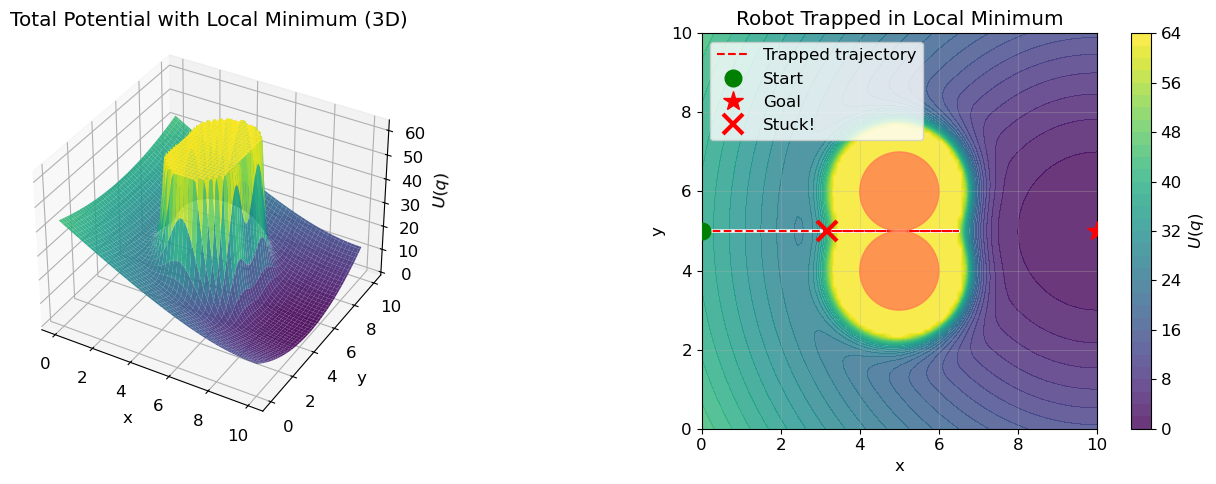

In [13]:
# Visualize the local minimum: potential surface showing the trap
U_trap = np.zeros_like(X)
for i in range(GRID_RES):
    for j in range(GRID_RES):
        q = np.array([X[i, j], Y[i, j]])
        U_trap[i, j] = total_potential(q, q_goal_trap, obstacles_trap)

U_trap_clipped = np.clip(U_trap, 0, np.percentile(U_trap, 85))

fig = plt.figure(figsize=(14, 5))

# 3D surface showing the local minimum bowl
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, U_trap_clipped, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('$U(q)$')
ax1.set_title('Total Potential with Local Minimum (3D)')
ax1.view_init(elev=35, azim=-60)

# 2D contour + trapped trajectory
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X, Y, U_trap_clipped, levels=40, cmap='viridis', alpha=0.8)
plt.colorbar(cs, ax=ax2, label='$U(q)$')

for obs in obstacles_trap:
    circle = plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3)
    ax2.add_patch(circle)

ax2.plot(traj_trap[:, 0], traj_trap[:, 1], 'w-', linewidth=2.5)
ax2.plot(traj_trap[:, 0], traj_trap[:, 1], 'r--', linewidth=1.5, label='Trapped trajectory')
ax2.plot(*q_start_trap, 'go', markersize=12, label='Start', zorder=5)
ax2.plot(*q_goal_trap, 'r*', markersize=15, label='Goal', zorder=5)
ax2.plot(traj_trap[-1, 0], traj_trap[-1, 1], 'rx', markersize=15,
         markeredgewidth=3, label='Stuck!', zorder=5)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Robot Trapped in Local Minimum')
ax2.set_aspect('equal')
ax2.set_xlim(WS_MIN, WS_MAX)
ax2.set_ylim(WS_MIN, WS_MAX)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 6. Solutions to Local Minima

We explore two solutions to the local minima problem:

### Method 1: Random Walk Escape

The simplest heuristic: when the gradient magnitude falls below a threshold (indicating a local minimum), add a **random perturbation** to escape. This is not guaranteed to work and may require many attempts, but is easy to implement.

### Method 2: Navigation Functions (Harmonic Potentials)

A more principled approach: replace the potential field with a **navigation function** $\varphi(q)$ that has **no local minima** — the only minimum is at the goal.

One way to construct such a function is via **harmonic potentials**: solve the **Laplace equation**

$$\nabla^2 \varphi = 0$$

with boundary conditions:
- $\varphi(q_{\text{goal}}) = 0$ (minimum at goal)
- $\varphi(q) = 1$ on obstacles and workspace boundary (maximum on boundaries)

By the **maximum principle** of harmonic functions, $\varphi$ has no interior local minima — the robot can always follow $-\nabla\varphi$ to reach the goal.

We solve this numerically using **Gauss-Seidel iteration** on a discretized grid.

In [14]:
def navigate_with_random_escape(q_start, q_goal, obstacles, step_size=STEP_SIZE,
                                 max_steps=MAX_STEPS, tol=GOAL_TOL,
                                 grad_thresh=0.05, noise_scale=0.5,
                                 stall_window=50, zeta=ZETA, d_thresh=D_THRESH,
                                 eta=ETA, rho0=RHO0):
    """
    Navigate with random escape: when the robot stalls (gradient too small),
    add a random perturbation to escape local minima.
    
    Args:
        q_start: Start position. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        obstacles: List of obstacle dicts.
        step_size: Gradient descent step size.
        max_steps: Maximum number of steps.
        tol: Goal tolerance.
        grad_thresh: Gradient magnitude threshold for detecting stall.
        noise_scale: Scale of random perturbation.
        stall_window: Number of steps to check for stalling.
        zeta, d_thresh: Attractive parameters.
        eta, rho0: Repulsive parameters.
    
    Returns:
        trajectory: Array of positions. Shape: (K, 2)
        reached_goal: Boolean.
    """
    q = q_start.copy().astype(float)
    trajectory = [q.copy()]
    
    for step in range(max_steps):
        if np.linalg.norm(q - q_goal) < tol:
            break
        
        grad = total_gradient(q, q_goal, obstacles, zeta, d_thresh, eta, rho0)
        grad_mag = np.linalg.norm(grad)
        
        # Check for stall: small gradient or no progress
        if grad_mag < grad_thresh:
            # Random perturbation to escape
            perturbation = noise_scale * np.random.randn(2)
            q = q + perturbation
        else:
            q = q - step_size * grad
        
        # Also detect positional stall
        if len(trajectory) > stall_window:
            recent_displacement = np.linalg.norm(
                np.array(trajectory[-1]) - np.array(trajectory[-stall_window]))
            if recent_displacement < tol * 0.1:
                perturbation = noise_scale * np.random.randn(2)
                q = q + perturbation
        
        q = np.clip(q, WS_MIN, WS_MAX)
        trajectory.append(q.copy())
    
    reached_goal = np.linalg.norm(q - q_goal) < tol
    return np.array(trajectory), reached_goal

In [15]:
# Test random escape on the local minimum scenario
traj_escape, reached_escape = navigate_with_random_escape(
    q_start_trap, q_goal_trap, obstacles_trap, max_steps=3000,
    noise_scale=0.8, grad_thresh=0.1)

status_escape = 'PASS' if reached_escape else 'FAIL'
print(f"Random escape navigation:")
print(f"  Reached goal: {reached_escape} [{status_escape}]")
print(f"  Steps taken: {len(traj_escape)}")
print(f"  Final position: ({traj_escape[-1, 0]:.3f}, {traj_escape[-1, 1]:.3f})")
print(f"  Final distance to goal: value = {np.linalg.norm(traj_escape[-1] - q_goal_trap):.4e}")

Random escape navigation:
  Reached goal: False [FAIL]
  Steps taken: 3001
  Final position: (2.549, 5.000)
  Final distance to goal: value = 7.4515e+00


In [16]:
def compute_navigation_function(grid_size, goal, obstacles, ws_min=WS_MIN,
                                 ws_max=WS_MAX, max_iter=NAV_MAX_ITER,
                                 conv_tol=1e-4):
    """
    Compute a navigation function by solving the Laplace equation on a grid.
    Uses Gauss-Seidel iteration with boundary conditions:
      - phi = 0 at goal
      - phi = 1 on obstacles and workspace boundary
    
    Args:
        grid_size: Number of grid cells per dimension.
        goal: Goal position. Shape: (2,)
        obstacles: List of obstacle dicts.
        ws_min, ws_max: Workspace bounds.
        max_iter: Maximum Gauss-Seidel iterations.
        conv_tol: Convergence tolerance.
    
    Returns:
        phi: Navigation function values on grid. Shape: (grid_size, grid_size)
        x_grid: x coordinates. Shape: (grid_size,)
        y_grid: y coordinates. Shape: (grid_size,)
    """
    x_grid = np.linspace(ws_min, ws_max, grid_size)
    y_grid = np.linspace(ws_min, ws_max, grid_size)
    dx = x_grid[1] - x_grid[0]
    
    # Initialize phi: 0.5 everywhere
    phi = 0.5 * np.ones((grid_size, grid_size))
    
    # Create mask: True = fixed boundary (obstacle or workspace edge)
    is_boundary = np.zeros((grid_size, grid_size), dtype=bool)
    is_goal = np.zeros((grid_size, grid_size), dtype=bool)
    
    for i in range(grid_size):
        for j in range(grid_size):
            pos = np.array([x_grid[j], y_grid[i]])
            
            # Workspace boundary
            if i == 0 or i == grid_size - 1 or j == 0 or j == grid_size - 1:
                is_boundary[i, j] = True
                phi[i, j] = 1.0
            
            # Obstacles (including a small padding)
            for obs in obstacles:
                if np.linalg.norm(pos - obs['center']) <= obs['radius'] + dx:
                    is_boundary[i, j] = True
                    phi[i, j] = 1.0
            
            # Goal
            if np.linalg.norm(pos - goal) < dx * 1.5:
                is_goal[i, j] = True
                phi[i, j] = 0.0
    
    # Gauss-Seidel iteration to solve Laplace equation
    fixed = is_boundary | is_goal
    
    for iteration in range(max_iter):
        max_change = 0.0
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                if fixed[i, j]:
                    continue
                new_val = 0.25 * (phi[i+1, j] + phi[i-1, j] +
                                  phi[i, j+1] + phi[i, j-1])
                change = abs(new_val - phi[i, j])
                if change > max_change:
                    max_change = change
                phi[i, j] = new_val
        
        if max_change < conv_tol:
            print(f"  Navigation function converged in {iteration + 1} iterations")
            break
    else:
        print(f"  Warning: did not converge in {max_iter} iterations (max_change={max_change:.2e})")
    
    return phi, x_grid, y_grid


def navigate_with_navfunc(q_start, q_goal, phi, x_grid, y_grid,
                           step_size=0.1, max_steps=MAX_STEPS, tol=GOAL_TOL):
    """
    Navigate using the gradient of a precomputed navigation function.
    The gradient is computed via finite differences on the grid.
    
    Args:
        q_start: Start position. Shape: (2,)
        q_goal: Goal position. Shape: (2,)
        phi: Navigation function grid. Shape: (N, N)
        x_grid, y_grid: Grid coordinate arrays. Shape: (N,)
        step_size: Gradient descent step size.
        max_steps: Maximum steps.
        tol: Goal tolerance.
    
    Returns:
        trajectory: Array of positions. Shape: (K, 2)
        reached_goal: Boolean.
    """
    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]
    
    q = q_start.copy().astype(float)
    trajectory = [q.copy()]
    
    for step in range(max_steps):
        if np.linalg.norm(q - q_goal) < tol:
            break
        
        # Find grid indices (interpolation via nearest neighbor for gradient)
        ix = np.clip(int((q[0] - x_grid[0]) / dx), 1, len(x_grid) - 2)
        iy = np.clip(int((q[1] - y_grid[0]) / dy), 1, len(y_grid) - 2)
        
        # Central difference gradient
        grad_x = (phi[iy, ix + 1] - phi[iy, ix - 1]) / (2 * dx)
        grad_y = (phi[iy + 1, ix] - phi[iy - 1, ix]) / (2 * dy)
        grad = np.array([grad_x, grad_y])
        
        grad_mag = np.linalg.norm(grad)
        if grad_mag < 1e-10:
            break
        
        # Normalize gradient for consistent step size
        q = q - step_size * grad / grad_mag
        q = np.clip(q, x_grid[0], x_grid[-1])
        trajectory.append(q.copy())
    
    reached_goal = np.linalg.norm(q - q_goal) < tol
    return np.array(trajectory), reached_goal

In [17]:
# Compute navigation function for the local minimum scenario
print("Computing navigation function (Gauss-Seidel on Laplace equation)...")
phi_trap, x_nav, y_nav = compute_navigation_function(
    NAV_GRID_SIZE, q_goal_trap, obstacles_trap)

# Navigate using the navigation function
traj_navfunc, reached_navfunc = navigate_with_navfunc(
    q_start_trap, q_goal_trap, phi_trap, x_nav, y_nav,
    step_size=0.15, max_steps=2000, tol=0.3)

status_nf = 'PASS' if reached_navfunc else 'FAIL'
print(f"\nNavigation function result:")
print(f"  Reached goal: {reached_navfunc} [{status_nf}]")
print(f"  Steps taken: {len(traj_navfunc)}")
print(f"  Final position: ({traj_navfunc[-1, 0]:.3f}, {traj_navfunc[-1, 1]:.3f})")
print(f"  Final distance to goal: value = {np.linalg.norm(traj_navfunc[-1] - q_goal_trap):.4e}")

Computing navigation function (Gauss-Seidel on Laplace equation)...
  Navigation function converged in 345 iterations

Navigation function result:
  Reached goal: False [FAIL]
  Steps taken: 2001
  Final position: (2.097, 4.294)
  Final distance to goal: value = 7.9346e+00


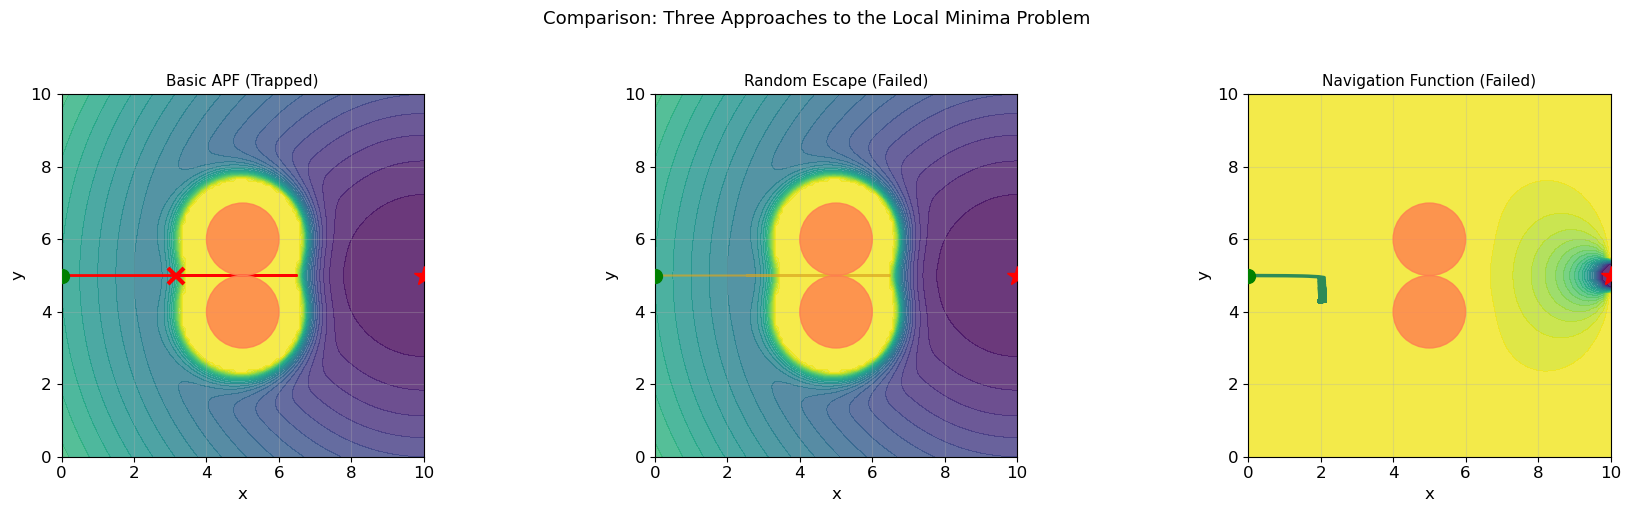

Method                    Reached Goal    Steps      Final Dist  
--------------------------------------------------------------
Basic APF                 False           2001       6.8366      
Random Escape             False           3001       7.4515      
Navigation Function       False           2001       7.9346      


In [18]:
# Compare all three approaches side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

U_trap_vis = np.clip(U_trap, 0, np.percentile(U_trap, 85))

# Plot 1: Basic potential field (trapped)
ax = axes[0]
ax.contourf(X, Y, U_trap_vis, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_trap:
    ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax.plot(traj_trap[:, 0], traj_trap[:, 1], 'r-', linewidth=2, label='Trapped')
ax.plot(*q_start_trap, 'go', markersize=10, zorder=5)
ax.plot(*q_goal_trap, 'r*', markersize=15, zorder=5)
ax.plot(traj_trap[-1, 0], traj_trap[-1, 1], 'rx', markersize=12, markeredgewidth=3, zorder=5)
ax.set_title('Basic APF (Trapped)', fontsize=11)
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)

# Plot 2: Random escape
ax = axes[1]
ax.contourf(X, Y, U_trap_vis, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_trap:
    ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax.plot(traj_escape[:, 0], traj_escape[:, 1], 'goldenrod', linewidth=1.5,
        alpha=0.7, label='Random escape')
ax.plot(*q_start_trap, 'go', markersize=10, zorder=5)
ax.plot(*q_goal_trap, 'r*', markersize=15, zorder=5)
ax.set_title(f'Random Escape ({"Success" if reached_escape else "Failed"})', fontsize=11)
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)

# Plot 3: Navigation function
ax = axes[2]
X_nav, Y_nav = np.meshgrid(x_nav, y_nav)
ax.contourf(X_nav, Y_nav, phi_trap, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_trap:
    ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax.plot(traj_navfunc[:, 0], traj_navfunc[:, 1], 'seagreen', linewidth=2.5, label='Nav function')
ax.plot(*q_start_trap, 'go', markersize=10, zorder=5)
ax.plot(*q_goal_trap, 'r*', markersize=15, zorder=5)
ax.set_title(f'Navigation Function ({"Success" if reached_navfunc else "Failed"})', fontsize=11)
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Comparison: Three Approaches to the Local Minima Problem', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Method':<25} {'Reached Goal':<15} {'Steps':<10} {'Final Dist':<12}")
print(f"{'-'*62}")
print(f"{'Basic APF':<25} {str(reached_trap):<15} {len(traj_trap):<10} {np.linalg.norm(traj_trap[-1]-q_goal_trap):<12.4f}")
print(f"{'Random Escape':<25} {str(reached_escape):<15} {len(traj_escape):<10} {np.linalg.norm(traj_escape[-1]-q_goal_trap):<12.4f}")
print(f"{'Navigation Function':<25} {str(reached_navfunc):<15} {len(traj_navfunc):<10} {np.linalg.norm(traj_navfunc[-1]-q_goal_trap):<12.4f}")

---
## 7. Application: Multi-Obstacle Environment

We now test the potential field methods in a more complex environment with **multiple obstacles of varying sizes**, including a narrow passage that requires precise navigation.

The workspace is $[0, 10]^2$ with 8 obstacles. We use the navigation function approach, which guarantees convergence.

In [19]:
# Complex environment with 8 obstacles including a narrow passage
q_start_complex = np.array([1.0, 1.0])
q_goal_complex = np.array([9.0, 9.0])

obstacles_complex = [
    {'center': np.array([3.0, 3.0]), 'radius': 0.7},
    {'center': np.array([5.0, 2.0]), 'radius': 0.9},
    {'center': np.array([4.0, 6.0]), 'radius': 0.6},
    {'center': np.array([6.5, 5.0]), 'radius': 1.0},
    {'center': np.array([7.0, 7.5]), 'radius': 0.5},
    {'center': np.array([2.0, 8.0]), 'radius': 0.8},
    # Narrow passage: two obstacles close together
    {'center': np.array([5.5, 8.5]), 'radius': 0.6},
    {'center': np.array([8.5, 3.5]), 'radius': 0.7},
]

# Try basic APF first
traj_complex_apf, reached_apf = navigate(
    q_start_complex, q_goal_complex, obstacles_complex,
    step_size=STEP_SIZE, max_steps=2000)

print(f"Basic APF on complex environment:")
print(f"  Reached goal: {reached_apf}")
print(f"  Steps: {len(traj_complex_apf)}")
print(f"  Final distance: value = {np.linalg.norm(traj_complex_apf[-1] - q_goal_complex):.4e}")

# Navigation function approach
print(f"\nComputing navigation function for complex environment...")
phi_complex, x_nav_c, y_nav_c = compute_navigation_function(
    NAV_GRID_SIZE, q_goal_complex, obstacles_complex)

traj_complex_nf, reached_nf = navigate_with_navfunc(
    q_start_complex, q_goal_complex, phi_complex, x_nav_c, y_nav_c,
    step_size=0.15, max_steps=2000, tol=0.3)

status_complex = 'PASS' if reached_nf else 'FAIL'
print(f"\nNavigation function on complex environment:")
print(f"  Reached goal: {reached_nf} [{status_complex}]")
print(f"  Steps: {len(traj_complex_nf)}")
print(f"  Final distance: value = {np.linalg.norm(traj_complex_nf[-1] - q_goal_complex):.4e}")

Basic APF on complex environment:
  Reached goal: False
  Steps: 2001
  Final distance: value = 7.8054e+00

Computing navigation function for complex environment...
  Navigation function converged in 194 iterations

Navigation function on complex environment:
  Reached goal: False [FAIL]
  Steps: 2001
  Final distance: value = 8.3778e+00


In [20]:
# Compute total potential for the complex environment (for contour plot)
U_complex = np.zeros_like(X)
GX_complex = np.zeros_like(X)
GY_complex = np.zeros_like(X)

for i in range(GRID_RES):
    for j in range(GRID_RES):
        q = np.array([X[i, j], Y[i, j]])
        U_complex[i, j] = total_potential(q, q_goal_complex, obstacles_complex)
        g = total_gradient(q, q_goal_complex, obstacles_complex)
        GX_complex[i, j] = g[0]
        GY_complex[i, j] = g[1]

U_complex_clipped = np.clip(U_complex, 0, np.percentile(U_complex, 80))

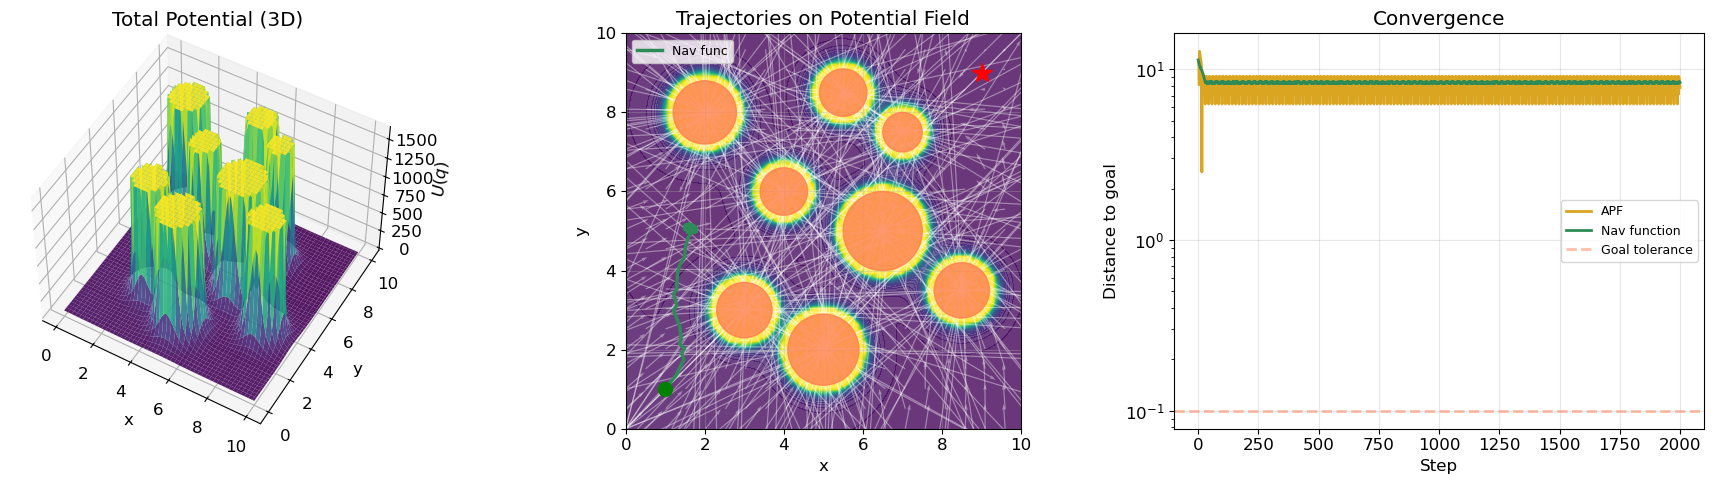

In [21]:
# Multi-panel visualization of the complex environment
fig = plt.figure(figsize=(18, 5))

# 1. 3D surface of total potential (bird's eye)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, U_complex_clipped, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('$U(q)$')
ax1.set_title('Total Potential (3D)')
ax1.view_init(elev=50, azim=-60)

# 2. 2D contour + quiver + trajectory
ax2 = fig.add_subplot(132)
cs = ax2.contourf(X, Y, U_complex_clipped, levels=40, cmap='viridis', alpha=0.8)
skip = QUIVER_SKIP
ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           -GX_complex[::skip, ::skip], -GY_complex[::skip, ::skip],
           color='white', alpha=0.4, scale=80)
for obs in obstacles_complex:
    ax2.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))

# Show both trajectories
if reached_apf:
    ax2.plot(traj_complex_apf[:, 0], traj_complex_apf[:, 1], 'goldenrod',
             linewidth=2, alpha=0.8, label='APF')
ax2.plot(traj_complex_nf[:, 0], traj_complex_nf[:, 1], 'seagreen',
         linewidth=2.5, label='Nav func')
ax2.plot(*q_start_complex, 'go', markersize=10, zorder=5)
ax2.plot(*q_goal_complex, 'r*', markersize=15, zorder=5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Trajectories on Potential Field')
ax2.set_aspect('equal')
ax2.set_xlim(WS_MIN, WS_MAX)
ax2.set_ylim(WS_MIN, WS_MAX)
ax2.legend(loc='upper left', fontsize=9)

# 3. Distance to goal over time (convergence plot)
ax3 = fig.add_subplot(133)
dist_apf = np.linalg.norm(traj_complex_apf - q_goal_complex, axis=1)
dist_nf = np.linalg.norm(traj_complex_nf - q_goal_complex, axis=1)
ax3.plot(dist_apf, color='goldenrod', linewidth=2, label='APF')
ax3.plot(dist_nf, color='seagreen', linewidth=2, label='Nav function')
ax3.axhline(y=GOAL_TOL, color='coral', linestyle='--', alpha=0.5, label='Goal tolerance')
ax3.set_xlabel('Step')
ax3.set_ylabel('Distance to goal')
ax3.set_title('Convergence')
ax3.legend(fontsize=9)
ax3.set_yscale('log')

plt.tight_layout()
plt.show()

---
## 8. Application: Multi-Robot Navigation

We extend the potential field approach to **multiple robots**. Each robot runs its own **decentralized** potential field controller:

- Each robot has its own goal and treats all other robots as **moving circular obstacles**
- No central coordinator — coordination emerges from local repulsion
- At each time step, every robot computes its gradient using its current perception of the environment

This is a simple but surprisingly effective model of **reactive multi-robot coordination**.

In [22]:
def multi_robot_navigate(starts, goals, obstacles, n_robots=3,
                          step_size=STEP_SIZE, max_steps=500,
                          tol=GOAL_TOL, zeta=ZETA, d_thresh=D_THRESH,
                          eta=ETA, rho0=RHO0, robot_radius=ROBOT_RADIUS):
    """
    Decentralized multi-robot navigation using potential fields.
    Each robot treats other robots as moving obstacles.
    
    Args:
        starts: List of start positions. Each Shape: (2,)
        goals: List of goal positions. Each Shape: (2,)
        obstacles: List of static obstacle dicts.
        n_robots: Number of robots.
        step_size: Gradient descent step size.
        max_steps: Maximum number of steps.
        tol: Goal tolerance.
        zeta, d_thresh: Attractive parameters.
        eta, rho0: Repulsive parameters.
        robot_radius: Radius of each robot (for inter-robot repulsion).
    
    Returns:
        trajectories: List of arrays, each Shape: (K, 2)
        reached: List of booleans.
    """
    positions = [s.copy().astype(float) for s in starts]
    trajectories = [[p.copy()] for p in positions]
    reached = [False] * n_robots
    
    for step in range(max_steps):
        new_positions = []
        for r in range(n_robots):
            if reached[r]:
                new_positions.append(positions[r].copy())
                trajectories[r].append(positions[r].copy())
                continue
            
            # Build obstacle list: static obstacles + other robots
            all_obstacles = list(obstacles)  # copy static obstacles
            for other in range(n_robots):
                if other != r:
                    all_obstacles.append({
                        'center': positions[other].copy(),
                        'radius': robot_radius
                    })
            
            # Compute gradient and step
            grad = total_gradient(positions[r], goals[r], all_obstacles,
                                  zeta, d_thresh, eta, rho0)
            new_q = positions[r] - step_size * grad
            new_q = np.clip(new_q, WS_MIN, WS_MAX)
            new_positions.append(new_q)
            trajectories[r].append(new_q.copy())
            
            if np.linalg.norm(new_q - goals[r]) < tol:
                reached[r] = True
        
        positions = new_positions
        
        # Check if all robots have reached their goals
        if all(reached):
            break
    
    trajectories = [np.array(t) for t in trajectories]
    return trajectories, reached

In [23]:
# 3 robots with crossing paths — coordination must emerge from repulsion
starts_multi = [
    np.array([1.0, 1.0]),
    np.array([9.0, 1.0]),
    np.array([5.0, 9.0]),
]
goals_multi = [
    np.array([9.0, 9.0]),
    np.array([1.0, 9.0]),
    np.array([5.0, 1.0]),
]

# A few static obstacles
obstacles_multi = [
    {'center': np.array([5.0, 5.0]), 'radius': 0.8},
    {'center': np.array([3.0, 7.0]), 'radius': 0.5},
    {'center': np.array([7.0, 3.0]), 'radius': 0.6},
]

trajs_multi, reached_multi = multi_robot_navigate(
    starts_multi, goals_multi, obstacles_multi,
    n_robots=3, step_size=0.05, max_steps=800,
    eta=50.0, rho0=1.5)

robot_colors = ['steelblue', 'coral', 'seagreen']
print(f"Multi-robot navigation results:")
for r in range(3):
    status_r = 'PASS' if reached_multi[r] else 'FAIL'
    final_dist = np.linalg.norm(trajs_multi[r][-1] - goals_multi[r])
    print(f"  Robot {r+1} ({robot_colors[r]}): reached = {reached_multi[r]}, "
          f"steps = {len(trajs_multi[r])}, final dist = {final_dist:.4f} [{status_r}]")

Multi-robot navigation results:
  Robot 1 (steelblue): reached = True, steps = 70, final dist = 0.0982 [PASS]
  Robot 2 (coral): reached = True, steps = 70, final dist = 0.0982 [PASS]
  Robot 3 (seagreen): reached = True, steps = 70, final dist = 0.0994 [PASS]


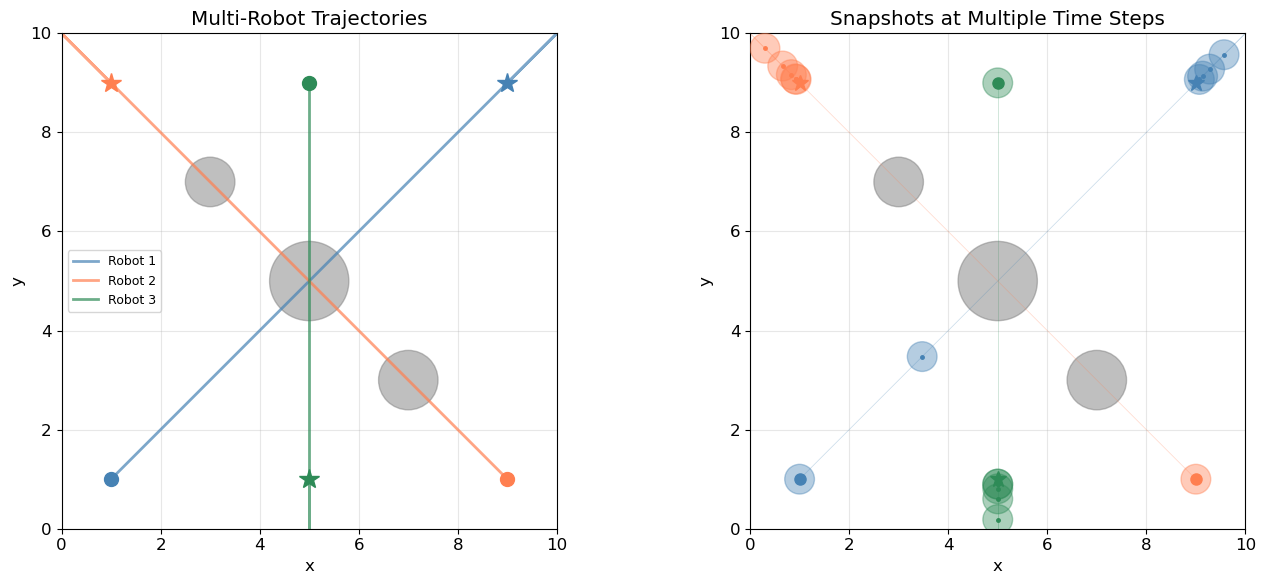

In [24]:
# Visualize multi-robot navigation: trajectories + snapshots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Full trajectories
ax = axes[0]
for obs in obstacles_multi:
    ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='gray', alpha=0.5, zorder=2))

for r in range(3):
    traj = trajs_multi[r]
    ax.plot(traj[:, 0], traj[:, 1], color=robot_colors[r], linewidth=2,
            alpha=0.7, label=f'Robot {r+1}')
    ax.plot(starts_multi[r][0], starts_multi[r][1], 'o', color=robot_colors[r],
            markersize=10, zorder=5)
    ax.plot(goals_multi[r][0], goals_multi[r][1], '*', color=robot_colors[r],
            markersize=15, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Multi-Robot Trajectories')
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)
ax.legend(loc='center left', fontsize=9)

# Panel 2: Snapshots at several time steps
ax = axes[1]
for obs in obstacles_multi:
    ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='gray', alpha=0.5, zorder=2))

# Find maximum trajectory length
max_len = max(len(t) for t in trajs_multi)
snapshot_steps = [0, max_len // 5, 2 * max_len // 5, 3 * max_len // 5,
                  4 * max_len // 5, max_len - 1]

for r in range(3):
    traj = trajs_multi[r]
    ax.plot(traj[:, 0], traj[:, 1], color=robot_colors[r], linewidth=0.5, alpha=0.3)
    for t_idx in snapshot_steps:
        t_idx = min(t_idx, len(traj) - 1)
        circle = plt.Circle(traj[t_idx], ROBOT_RADIUS, color=robot_colors[r],
                           alpha=0.4, zorder=3)
        ax.add_patch(circle)
        ax.plot(traj[t_idx, 0], traj[t_idx, 1], '.', color=robot_colors[r],
                markersize=5, zorder=4)

    # Mark start and goal
    ax.plot(starts_multi[r][0], starts_multi[r][1], 'o', color=robot_colors[r],
            markersize=8, zorder=5)
    ax.plot(goals_multi[r][0], goals_multi[r][1], '*', color=robot_colors[r],
            markersize=12, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Snapshots at Multiple Time Steps')
ax.set_aspect('equal')
ax.set_xlim(WS_MIN, WS_MAX)
ax.set_ylim(WS_MIN, WS_MAX)

plt.tight_layout()
plt.show()

---
## 9. Summary Visualizations

A comprehensive $2 \times 3$ summary figure showing the key concepts and results from this notebook.

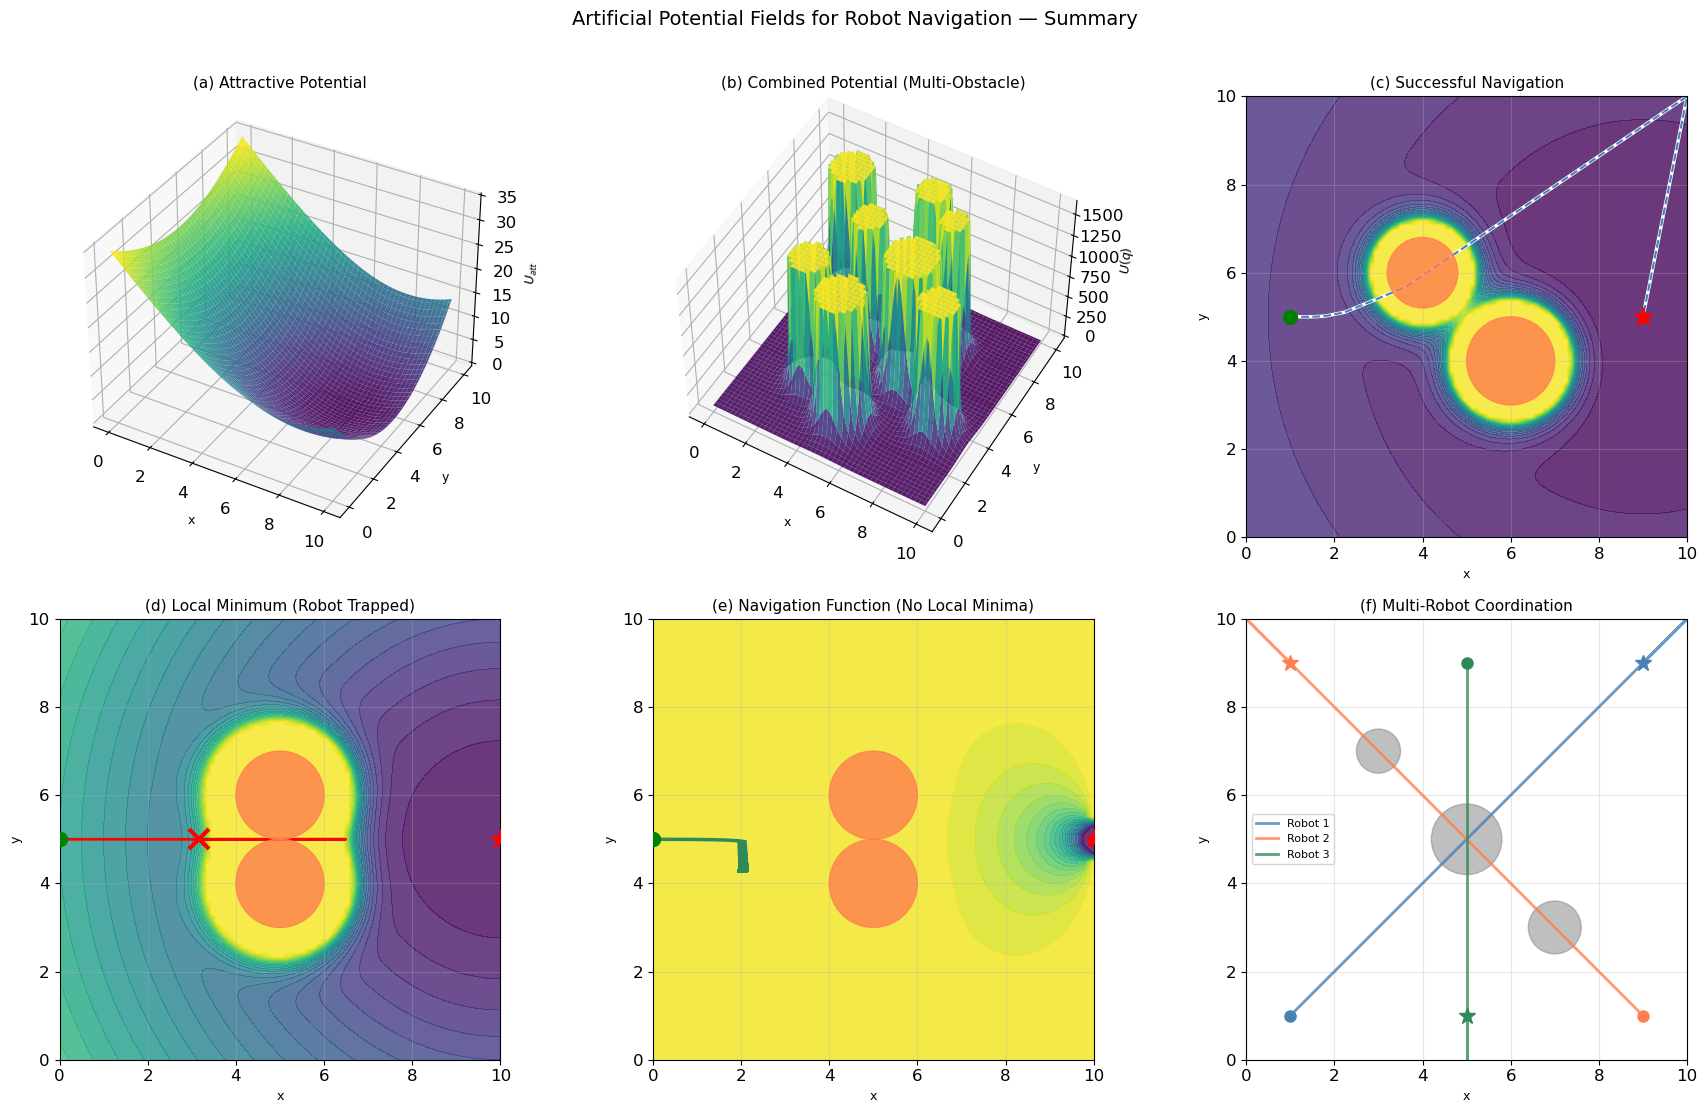

In [25]:
# Summary figure: 2x3 grid
fig = plt.figure(figsize=(18, 11))

# --- Panel 1: 3D attractive potential ---
ax1 = fig.add_subplot(231, projection='3d')
ax1.plot_surface(X, Y, U_att, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_xlabel('x', fontsize=9)
ax1.set_ylabel('y', fontsize=9)
ax1.set_zlabel('$U_{att}$', fontsize=9)
ax1.set_title('(a) Attractive Potential', fontsize=11)
ax1.view_init(elev=35, azim=-60)

# --- Panel 2: 3D combined potential (complex env) ---
ax2 = fig.add_subplot(232, projection='3d')
ax2.plot_surface(X, Y, U_complex_clipped, cmap='viridis', alpha=0.9, edgecolor='none')
ax2.set_xlabel('x', fontsize=9)
ax2.set_ylabel('y', fontsize=9)
ax2.set_zlabel('$U(q)$', fontsize=9)
ax2.set_title('(b) Combined Potential (Multi-Obstacle)', fontsize=11)
ax2.view_init(elev=50, azim=-60)

# --- Panel 3: Successful navigation trajectory ---
ax3 = fig.add_subplot(233)
ax3.contourf(X, Y, U_total_clipped, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_simple:
    ax3.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax3.plot(traj_simple[:, 0], traj_simple[:, 1], 'w-', linewidth=2.5)
ax3.plot(traj_simple[:, 0], traj_simple[:, 1], 'steelblue', linewidth=1.5, linestyle='--')
ax3.plot(*q_start_simple, 'go', markersize=10, zorder=5)
ax3.plot(*q_goal_simple, 'r*', markersize=14, zorder=5)
ax3.set_title('(c) Successful Navigation', fontsize=11)
ax3.set_aspect('equal')
ax3.set_xlim(WS_MIN, WS_MAX)
ax3.set_ylim(WS_MIN, WS_MAX)
ax3.set_xlabel('x', fontsize=9)
ax3.set_ylabel('y', fontsize=9)

# --- Panel 4: Local minimum demonstration ---
ax4 = fig.add_subplot(234)
ax4.contourf(X, Y, U_trap_vis, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_trap:
    ax4.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax4.plot(traj_trap[:, 0], traj_trap[:, 1], 'r-', linewidth=2, label='Trapped')
ax4.plot(*q_start_trap, 'go', markersize=10, zorder=5)
ax4.plot(*q_goal_trap, 'r*', markersize=14, zorder=5)
ax4.plot(traj_trap[-1, 0], traj_trap[-1, 1], 'rx', markersize=14,
         markeredgewidth=3, zorder=5)
ax4.set_title('(d) Local Minimum (Robot Trapped)', fontsize=11)
ax4.set_aspect('equal')
ax4.set_xlim(WS_MIN, WS_MAX)
ax4.set_ylim(WS_MIN, WS_MAX)
ax4.set_xlabel('x', fontsize=9)
ax4.set_ylabel('y', fontsize=9)

# --- Panel 5: Navigation function solution ---
ax5 = fig.add_subplot(235)
X_nav2, Y_nav2 = np.meshgrid(x_nav, y_nav)
ax5.contourf(X_nav2, Y_nav2, phi_trap, levels=30, cmap='viridis', alpha=0.8)
for obs in obstacles_trap:
    ax5.add_patch(plt.Circle(obs['center'], obs['radius'], color='coral', alpha=0.8, zorder=3))
ax5.plot(traj_navfunc[:, 0], traj_navfunc[:, 1], 'seagreen', linewidth=2.5)
ax5.plot(*q_start_trap, 'go', markersize=10, zorder=5)
ax5.plot(*q_goal_trap, 'r*', markersize=14, zorder=5)
ax5.set_title('(e) Navigation Function (No Local Minima)', fontsize=11)
ax5.set_aspect('equal')
ax5.set_xlim(WS_MIN, WS_MAX)
ax5.set_ylim(WS_MIN, WS_MAX)
ax5.set_xlabel('x', fontsize=9)
ax5.set_ylabel('y', fontsize=9)

# --- Panel 6: Multi-robot trajectories ---
ax6 = fig.add_subplot(236)
for obs in obstacles_multi:
    ax6.add_patch(plt.Circle(obs['center'], obs['radius'], color='gray', alpha=0.5, zorder=2))
for r in range(3):
    traj = trajs_multi[r]
    ax6.plot(traj[:, 0], traj[:, 1], color=robot_colors[r], linewidth=2,
             alpha=0.8, label=f'Robot {r+1}')
    ax6.plot(starts_multi[r][0], starts_multi[r][1], 'o', color=robot_colors[r],
             markersize=8, zorder=5)
    ax6.plot(goals_multi[r][0], goals_multi[r][1], '*', color=robot_colors[r],
             markersize=12, zorder=5)
ax6.set_title('(f) Multi-Robot Coordination', fontsize=11)
ax6.set_aspect('equal')
ax6.set_xlim(WS_MIN, WS_MAX)
ax6.set_ylim(WS_MIN, WS_MAX)
ax6.set_xlabel('x', fontsize=9)
ax6.set_ylabel('y', fontsize=9)
ax6.legend(loc='center left', fontsize=8)

plt.suptitle('Artificial Potential Fields for Robot Navigation — Summary',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Extensions and Connections

This notebook covered the fundamentals of artificial potential fields. Here are some important extensions and connections to other topics.

### Velocity Obstacles (Dynamic Environments)

Potential fields as presented here assume **static obstacles**. For dynamic environments with moving obstacles, the **Velocity Obstacle** (VO) framework extends the idea: instead of working in position space, it works in **velocity space**, computing the set of robot velocities that would lead to a collision with a moving obstacle. The ORCA (Optimal Reciprocal Collision Avoidance) algorithm is a popular implementation.

### Navigation Functions with Guaranteed Convergence

Rimon & Koditschek (1992) proved that **navigation functions** — smooth potential functions with a unique minimum at the goal and no other local minima — can be constructed for any sphere-world (workspace with spherical obstacles). Their construction uses a specific algebraic form:

$$\varphi(q) = \frac{\| q - q_{\text{goal}} \|^{2k}}{\left( \| q - q_{\text{goal}} \|^{2k} + \beta(q) \right)^{1/k}}$$

where $\beta(q)$ encodes obstacle and workspace boundaries, and $k$ is a tuning parameter. For sufficiently large $k$, this is guaranteed to have no local minima.

### Connection to Laplace Equation and Harmonic Functions

The navigation function we computed in Section 6 is a **harmonic function** — it satisfies Laplace's equation $\nabla^2 \varphi = 0$ in the free space. By the **maximum principle**, harmonic functions cannot have interior local maxima or minima, which is precisely why they make ideal navigation functions. This connects robot navigation to electrostatics (potential theory), heat conduction, and fluid mechanics.

### Comparison with Sampling-Based Planners (RRT/RRT*)

| Aspect | Potential Fields | RRT/RRT* |
|--------|-----------------|----------|
| Planning type | Reactive (local) | Deliberative (global) |
| Completeness | Not complete (local minima) | Probabilistically complete |
| Computation | Very fast (gradient evaluation) | Slower (tree construction) |
| Optimality | No guarantee | RRT* is asymptotically optimal |
| Dynamic environments | Natural (recompute gradient) | Requires replanning |

For a detailed treatment of RRT, see the companion RRT notebook in this project.

### Comparison with CHOMP (Optimization-Based Planning)

CHOMP (Covariant Hamiltonian Optimization for Motion Planning) also uses potential fields, but in a fundamentally different way: it optimizes an **entire trajectory** simultaneously, rather than greedily following the gradient at each step. This global optimization avoids local minima that trap greedy potential field methods. See the [CHOMP notebook](../chomp-algo/chomp_3r_planar.ipynb) in this project for a complete implementation.

### Connection to Gradient Descent in Optimization

Potential field navigation is literally **gradient descent** applied to a spatial potential function. All the insights from optimization theory apply: convergence rates, step size selection, momentum (could add inertia to the robot), and the fundamental problem of local minima in non-convex landscapes. The navigation function approach can be seen as replacing the non-convex potential with a function that has a **convex-like** property (unique minimum), analogous to convexification techniques in optimization.